# Zoolog

Zoolog, penguen türlerini tanıma konusunda uzmandır. Uzmanımızın adlandırabildiği 3 penguen türü şunlardır:

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/01-Fundamentals-of-Machine-Learning/palmer-penguins.png" width=1000>

Peki siz onları ayırt edebiliyor musunuz?


## Görev

Penguenler hakkında hiçbir şey bilmediğimiz için, bu penguenleri özelliklerine göre sınıflandırmak için bir Makine Öğrenimi algoritması kullanalım.

## Dataset’i yükleyin

Seaborn [Penguins dataset](https://github.com/mwaskom/seaborn-data/blob/master/penguins.csv)’ini bir DataFrame içine yükleyelim. İşleri kolaylaştırmak için `nans` değerlerinden kurtulun! Aşağıdaki çıktıyı elde etmelisiniz:

<img src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/01-Fundamentals-of-Machine-Learning/penguin-df.png' width=600>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


penguin_df = pd.read_csv('data/penguins.csv')

print("İlk 5 satır:")
print(penguin_df.head())
print("\n")

print("Dataset Bilgileri:")
print(penguin_df.info())
print("\n")

print("İstatistiksel Özet:")
print(penguin_df.describe())
print("\n")

print("Eksik Değerler:")
print(penguin_df.isnull().sum())
print("\n")

penguin_df = penguin_df.dropna()
print(f"Önceki boyut: {penguin_df.shape}")
print(f"Yeni boyut: {penguin_df.shape}")
print(f"Silinen satır sayısı: {penguin_df.shape[0] - penguin_df.shape[0]}")

# Sütun isimleri
print("Sütunlar:")
print(penguin_df.columns.tolist())
print("\n")


print(f"Dataset boyutu: {penguin_df.shape[0]} satır, {penguin_df.shape[1]} sütun")


İlk 5 satır:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


Dataset Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342

❓Penguenlerin özellikleri nelerdir?

<img src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/gentoo.png' width=700>

❓Bu veri setinde kaç tür penguen var?

In [14]:
print("Penguen Türleri:")
print(df_clean['species'].unique())
print(f"\nToplam tür sayısı: {df_clean['species'].nunique()}")

print("\nTür dağılımı:")
print(df_clean['species'].value_counts())

Penguen Türleri:
['Adelie' 'Chinstrap' 'Gentoo']

Toplam tür sayısı: 3

Tür dağılımı:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


❓Veri setinde her tür için kaç gözlem var?

In [15]:
# Her tür için kaç gözlem var?
print("="*50)
print("TÜR BAZINDA GÖZLEM SAYILARI")
print("="*50)

# Detaylı sayım
tur_dagilimi = df_clean['species'].value_counts()
print(tur_dagilimi)
print("\n")

# Yüzdelik dağılım
print("Yüzdelik Dağılım:")
tur_yuzde = df_clean['species'].value_counts(normalize=True) * 100
print(tur_yuzde.round(2))
print("\n")

# Toplam
print(f"Toplam gözlem sayısı: {len(df_clean)}")
print(f"Toplam tür sayısı: {df_clean['species'].nunique()}")

TÜR BAZINDA GÖZLEM SAYILARI
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


Yüzdelik Dağılım:
species
Adelie       43.84
Gentoo       35.74
Chinstrap    20.42
Name: proportion, dtype: float64


Toplam gözlem sayısı: 333
Toplam tür sayısı: 3


In [16]:
penguin_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


##  Veri görselleştirme (Data visualization)

‘bill_length_mm’ değerini ‘bill_depth_mm’ değerine göre, her tür için farklı bir renk kullanarak grafikte gösterin:

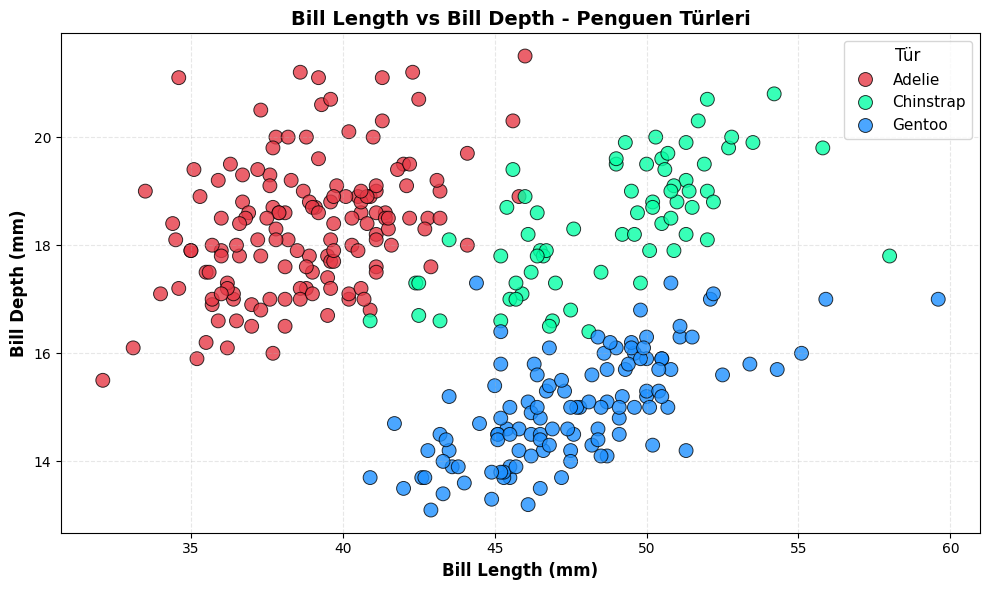

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean,
                x='bill_length_mm',
                y='bill_depth_mm',
                hue='species',
                palette=['#E63946', '#06FFA5', '#1E90FF'],
                s=100,
                alpha=0.8,
                edgecolor='black',
                linewidth=0.7)
plt.xlabel('Bill Length (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Bill Depth (mm)', fontsize=12, fontweight='bold')
plt.title('Bill Length vs Bill Depth - Penguen Türleri', fontsize=14, fontweight='bold')
plt.legend(title='Tür', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

❓Gözlemlerinize dayanarak bu türleri ayırt edebiliyor musunuz?

**gentoo** türü, diğer 2 türe göre açıkça daha uzun yüzgeçlere sahip gibi görünüyor.

## Modelleme

Çoklu sınıf sorununu çözmek için iki strateji vardır:

- Bire bir (One vs One)
- Bire tüm (Bire geri kalan)(One vs All)


### One vs One
- Dataset içindeki **her bir sınıf çifti için bir model** eğitilir
- Tahmin aşamasında, **en fazla oyu alan sınıf** seçilir

<img src='images/ovo_multiclass.png' width=500 style='margin:auto'> 


👍 Sınıf çiftlerine özgü farkları dikkate alır


👎 Çok sayıda alt model oluşturur: hesaplama açısından maliyetlidir


### One vs Rest (One vs All)

- **Her bir sınıf için**, diğer tüm sınıflara karşı **tek bir model** eğitilir
- Tahmin aşamasında, **en yüksek olasılığa sahip sınıf** seçilir

<img src='images/ova_multiclass.png' width=500 style='margin:auto'> 

👍 Hesaplama açısından daha az maliyetlidir


👎 Sınıfların bir araya getirilmesiyle, sınıf çiftlerine özgü farklar kaybolur ve etkileri azalır

## One vs Rest

👇 Penguen türünü **sayısal (numerical)** feature’lara göre tahmin eden bir modeli değerlendirin. scikit-learn içinde, temel model olarak LogisticRegression kullanan bir One vs Rest multi-class classification uygulamak için doğru classifier’ı bulun. Modeli cross-validation ile değerlendirin ve bunun ne kadar süre aldığını kaydedin.

/home/ubtuna/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


ONE vs REST - LOGISTIC REGRESSION

Accuracy: 1.0000
Train seti boyutu: 266
Test seti boyutu: 67

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



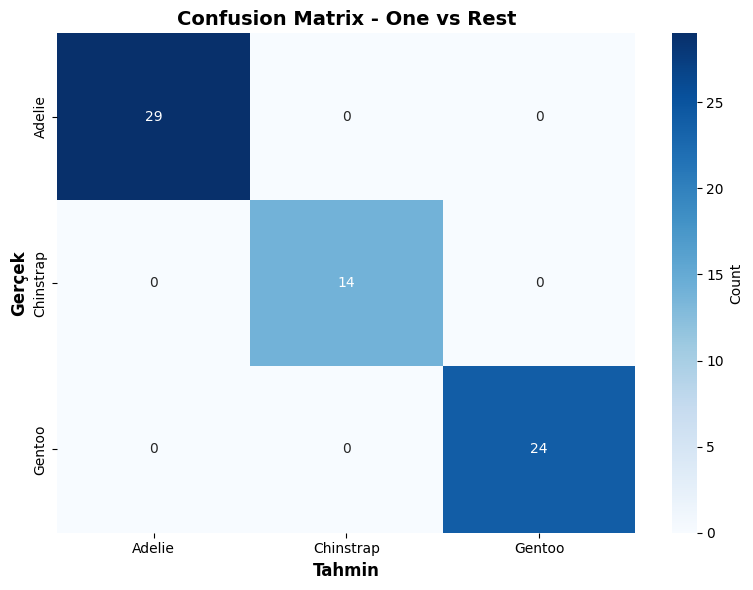

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns


X = penguin_df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = penguin_df['species']


le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,
                                                      test_size=0.2,
                                                      random_state=42,
                                                      stratify=y_encoded)


model_ovr = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
model_ovr.fit(X_train, y_train)


y_pred = model_ovr.predict(X_test)


print("="*60)
print("ONE vs REST - LOGISTIC REGRESSION")
print("="*60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Train seti boyutu: {X_train.shape[0]}")
print(f"Test seti boyutu: {X_test.shape[0]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Tahmin', fontsize=12, fontweight='bold')
plt.ylabel('Gerçek', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - One vs Rest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## One vs One

👇 Bu sefer bir `OneVsOneClassifier` implement edin.

Yine cross-validation ile değerlendirin ve bunun ne kadar süre aldığını kaydedin.

ONE vs ONE - LOGISTIC REGRESSION (SCALED)

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67


CROSS-VALIDATION SONUÇLARI (10-Fold)
Ortalama Accuracy: 0.9789
Standart Sapma: 0.0304

ZOOLOG vs MODEL
Zoolog: 90.0%
Model: 97.9%
🎉 Zooloğu geçtik!


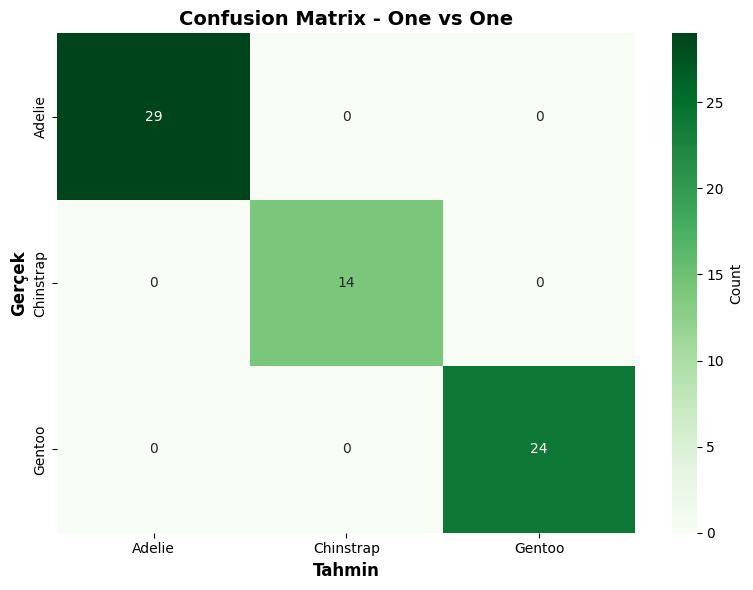

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsOneClassifier

# Veriyi scale et (önemli!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Yeniden train-test split
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# One vs One (multi_class parametresini kaldır)
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter=2000, random_state=42))
model_ovo.fit(X_train_scaled, y_train)

# Tahmin
y_pred_ovo = model_ovo.predict(X_test_scaled)

# Performans
print("="*60)
print("ONE vs ONE - LOGISTIC REGRESSION (SCALED)")
print("="*60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_ovo):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ovo, target_names=le.classes_))

# Cross-Validation
cv_scores = cross_val_score(model_ovo, X_scaled, y_encoded, cv=10, scoring='accuracy')

print("\n" + "="*60)
print("CROSS-VALIDATION SONUÇLARI (10-Fold)")
print("="*60)
print(f"Ortalama Accuracy: {cv_scores.mean():.4f}")
print(f"Standart Sapma: {cv_scores.std():.4f}")

# Zoolog karşılaştırma
zoolog_accuracy = 0.90
print("\n" + "="*60)
print("ZOOLOG vs MODEL")
print("="*60)
print(f"Zoolog: {zoolog_accuracy * 100:.1f}%")
print(f"Model: {cv_scores.mean() * 100:.1f}%")
if cv_scores.mean() > zoolog_accuracy:
    print("🎉 Zooloğu geçtik!")

    cm_ovo = confusion_matrix(y_test, y_pred_ovo)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ovo, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Tahmin', fontsize=12, fontweight='bold')
plt.ylabel('Gerçek', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - One vs One', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ℹ️ Her iki modelin de çok benzer doğruluklara sahip olduğunu görüyoruz. Neden? <br><br>
Öncelikle, her iki model de sınıflandırması görece kolay olan bir dataset üzerinde oldukça iyi bir performans sergiliyor. İkinci olarak, ayırt edilmesi gereken yalnızca üç sınıf olduğunda, hem OvO hem de OvR yaklaşımları aslında **3 adet alt modelin** eğitilmesiyle sonuçlanır! Bu nedenle, çok benzer doğruluklar elde etmemiz beklenir.

❓ Zoolog, 10 denemenin 9’unda doğru türü bulabiliyor; siz onu geçebilir misiniz?

<details>
<summary> 👉Çözüm </summary>
Yaklaşık %98’lik bir ortalama doğruluk elde etmelisiniz; bu da %90’dan daha yüksektir. Yani algoritmamız zoologu geçiyor!

</details>

# 🏁 